# PDF Text Extraction Investigation with PyMuPDF (fitz)

This notebook demonstrates how `fitz` extracts text from a PDF file,
using the same logic as `load_from_pdf` in the ingestion pipeline.

In [1]:
import fitz  # PyMuPDF
from pathlib import Path
from langchain_core.documents import Document

In [2]:
# === SET YOUR PDF PATH HERE ===
PDF_PATH = r"d:\Data Science1\EFESOBOT\data\EFESO_E2E_Inflation_Management.pdf"

In [ ]:
def load_text_from_pdf(file_path: str) -> list[Document]:
    """
    Extract only text documents from a PDF using fitz (same logic as load_from_pdf).
    Skips image extraction to focus purely on text investigation.
    """
    documents = []
    pdf_path = str(file_path)

    doc = fitz.open(pdf_path)
    print(f"PDF: {Path(pdf_path).name}")
    print(f"Total pages: {len(doc)}")
    print("=" * 60)

    for page_num, page in enumerate(doc):
        # Extract text from page (same as the pipeline)
        text = page.get_text()

        if text.strip():
            text_doc = Document(
                page_content=text,
                metadata={
                    "page": page_num + 1,
                    "type": "text",
                    "source": pdf_path,
                    "file_name": Path(pdf_path).name
                }
            )
            documents.append(text_doc)
        else:
            print(f"[Page {page_num + 1}] -- No text found (image-only page?) --")

    doc.close()
    return documents

In [ ]:
# Run the extraction
documents = load_text_from_pdf(PDF_PATH)
print(f"\nTotal text documents extracted: {len(documents)}")

In [ ]:
# Investigate each document
for i, doc in enumerate(documents):
    page = doc.metadata["page"]
    content = doc.page_content
    print(f"\n{'=' * 60}")
    print(f"Document [{i}] | Page {page} | Characters: {len(content)}")
    print(f"Metadata: {doc.metadata}")
    print(f"{'-' * 60}")
    print(content)
    print(f"{'=' * 60}")

# PDFPlumber Extraction

Now let's extract text from the same PDF using **pdfplumber** and compare the results with fitz.

In [ ]:
import pdfplumber

In [ ]:
def load_text_from_pdf_plumber(file_path: str) -> list[Document]:
    """
    Extract text documents from a PDF using pdfplumber.
    Same structure as the fitz version for easy comparison.
    """
    documents = []
    pdf_path = str(file_path)

    with pdfplumber.open(pdf_path) as pdf:
        print(f"PDF: {Path(pdf_path).name}")
        print(f"Total pages: {len(pdf.pages)}")
        print("=" * 60)

        for page_num, page in enumerate(pdf.pages):
            text = page.extract_text()

            if text and text.strip():
                text_doc = Document(
                    page_content=text,
                    metadata={
                        "page": page_num + 1,
                        "type": "text",
                        "source": pdf_path,
                        "file_name": Path(pdf_path).name
                    }
                )
                documents.append(text_doc)
            else:
                print(f"[Page {page_num + 1}] -- No text found (image-only page?) --")

    return documents

In [ ]:
# Run pdfplumber extraction
plumber_documents = load_text_from_pdf_plumber(PDF_PATH)
print(f"\nTotal text documents extracted: {len(plumber_documents)}")

In [ ]:
# Investigate each pdfplumber document
for i, doc in enumerate(plumber_documents):
    page = doc.metadata["page"]
    content = doc.page_content
    print(f"\n{'=' * 60}")
    print(f"Document [{i}] | Page {page} | Characters: {len(content)}")
    print(f"Metadata: {doc.metadata}")
    print(f"{'-' * 60}")
    print(content)
    print(f"{'=' * 60}")

# Side-by-Side Comparison: fitz vs pdfplumber

Compare the extracted text from both libraries page by page.

In [ ]:
# Side-by-side comparison per page
max_pages = max(len(documents), len(plumber_documents))

print(f"{'FITZ':>30} | {'PDFPLUMBER':<30}")
print(f"{'─' * 30}─┼─{'─' * 30}")

for i in range(max_pages):
    fitz_chars = len(documents[i].page_content) if i < len(documents) else 0
    plumber_chars = len(plumber_documents[i].page_content) if i < len(plumber_documents) else 0
    fitz_page = documents[i].metadata["page"] if i < len(documents) else "N/A"
    plumber_page = plumber_documents[i].metadata["page"] if i < len(plumber_documents) else "N/A"
    diff = fitz_chars - plumber_chars
    diff_str = f"(+{diff})" if diff > 0 else f"({diff})" if diff < 0 else "(same)"

    print(f"  Page {fitz_page}: {fitz_chars:>5} chars   |   Page {plumber_page}: {plumber_chars:>5} chars   {diff_str}")

print(f"\n{'=' * 65}")
print(f"  FITZ total chars:      {sum(len(d.page_content) for d in documents)}")
print(f"  PDFPLUMBER total chars: {sum(len(d.page_content) for d in plumber_documents)}")
print(f"  FITZ total docs:       {len(documents)}")
print(f"  PDFPLUMBER total docs:  {len(plumber_documents)}")

In [ ]:
# Detailed diff for each page — see exactly what each library captures differently
for i in range(max_pages):
    fitz_text = documents[i].page_content if i < len(documents) else "(no text)"
    plumber_text = plumber_documents[i].page_content if i < len(plumber_documents) else "(no text)"
    page_num = i + 1

    print(f"\n{'#' * 80}")
    print(f"  PAGE {page_num}")
    print(f"{'#' * 80}")

    print(f"\n>>> FITZ output ({len(fitz_text)} chars):")
    print(f"{'-' * 40}")
    print(fitz_text)

    print(f"\n>>> PDFPLUMBER output ({len(plumber_text)} chars):")
    print(f"{'-' * 40}")
    print(plumber_text)

    # Highlight key differences
    fitz_lines = set(fitz_text.strip().splitlines())
    plumber_lines = set(plumber_text.strip().splitlines())

    only_fitz = fitz_lines - plumber_lines
    only_plumber = plumber_lines - fitz_lines

    if only_fitz or only_plumber:
        print(f"\n>>> DIFFERENCES:")
        if only_fitz:
            print(f"  Lines ONLY in fitz ({len(only_fitz)}):")
            for line in sorted(only_fitz)[:10]:
                print(f"    + {line[:100]}")
        if only_plumber:
            print(f"  Lines ONLY in pdfplumber ({len(only_plumber)}):")
            for line in sorted(only_plumber)[:10]:
                print(f"    + {line[:100]}")
    else:
        print(f"\n>>> No line-level differences found.")

# Docling Extraction (with LangChain Integration)

Now let's extract text using **Docling** — an open-source document parser by IBM that produces rich structured output
(layout-aware, table-aware). It has a native LangChain integration via `langchain-docling`.

Two export modes:
- `DOC_CHUNKS` — Docling chunks the document itself into separate LangChain Documents (with heading hierarchy metadata)
- `MARKDOWN` — exports the entire document as a single Markdown string per file

In [3]:
from langchain_docling import DoclingLoader
from langchain_docling.loader import ExportType

d:\Data Science1\EFESOBOT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Mode 1: DOC_CHUNKS — Docling's own intelligent chunking

Docling parses the document layout, detects headings/tables/lists, and chunks accordingly.
Each chunk gets rich metadata (heading hierarchy, document structure info).

In [4]:
# Load with DOC_CHUNKS mode (Docling's own chunking)
docling_chunk_loader = DoclingLoader(
    file_path=PDF_PATH,
    export_type=ExportType.DOC_CHUNKS,
)
docling_chunk_docs = docling_chunk_loader.load()

print(f"PDF: {Path(PDF_PATH).name}")
print(f"Total chunks produced by Docling: {len(docling_chunk_docs)}")
print("=" * 60)

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-03-06 02:12:58,650 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-06 02:12:58,671 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-06 02:12:58,673 [RapidOCR] main.py:53: Using D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-06 02:12:58,835 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-06 02:12:58,839 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-06 02:12:58,841 [RapidOCR] main.py:53: Using D:\Data Sc

PDF: EFESO_E2E_Inflation_Management.pdf
Total chunks produced by Docling: 18


In [5]:
# Investigate each Docling chunk
for i, doc in enumerate(docling_chunk_docs):
    content = doc.page_content
    print(f"\n{'=' * 60}")
    print(f"Chunk [{i}] | Characters: {len(content)}")
    print(f"Metadata: {doc.metadata}")
    print(f"{'-' * 60}")
    print(content)
    print(f"{'=' * 60}")


Chunk [0] | Characters: 92
Metadata: {'source': 'd:\\Data Science1\\EFESOBOT\\data\\EFESO_E2E_Inflation_Management.pdf', 'dl_meta': {'schema_name': 'docling_core.transforms.chunker.DocMeta', 'version': '1.0.0', 'doc_items': [{'self_ref': '#/texts/15', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'text', 'prov': [{'page_no': 1, 'bbox': {'l': 716.6129557291666, 't': 340.39286295572913, 'r': 930.48388671875, 'b': 330.75, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 21]}]}, {'self_ref': '#/texts/16', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'text', 'prov': [{'page_no': 1, 'bbox': {'l': 717.065, 't': 128.91200000000003, 'r': 930.161, 'b': 119.55200000000002, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 45]}]}, {'self_ref': '#/texts/17', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'text', 'prov': [{'page_no': 1, 'bbox': {'l': 713.432, 't': 107.60199999999998, 'r': 932.456, 'b': 

## Mode 2: MARKDOWN — Full document as Markdown

Docling converts the entire PDF into a single Markdown string, preserving headings, tables, and structure.

In [6]:
# Load with MARKDOWN mode (full document as one Markdown string)
docling_md_loader = DoclingLoader(
    file_path=PDF_PATH,
    export_type=ExportType.MARKDOWN,
)
docling_md_docs = docling_md_loader.load()

print(f"PDF: {Path(PDF_PATH).name}")
print(f"Total documents (should be 1): {len(docling_md_docs)}")
print(f"Total characters: {len(docling_md_docs[0].page_content)}")
print(f"Metadata: {docling_md_docs[0].metadata}")
print("=" * 60)
print(docling_md_docs[0].page_content)

[INFO] 2026-02-26 01:42:18,769 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-02-26 01:42:18,793 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-02-26 01:42:18,794 [RapidOCR] main.py:53: Using D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-02-26 01:42:18,936 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-02-26 01:42:18,952 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-02-26 01:42:18,953 [RapidOCR] main.py:53: Using D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-02-26 01:42:19,045 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-02-26 01:42:19,091 [RapidOCR] download_file.p

PDF: EFESO_Big_Data.pdf
Total documents (should be 1): 1
Total characters: 1525
Metadata: {'source': 'd:\\Data Science1\\EFESOBOT\\data\\EFESO_Big_Data.pdf'}
## =EFESO

MANAGEMENTCONSULTANTS

P R O C U R E M E N T

INSIGHT

© EFESO

1

Every industry is confronted with an enormous increase of data paired with a high data complexity

## Global data increase 1

Global industries are experiencing an unprecedented explosion of data

444% increase from 2020 to 2027

## Multiple data sources

Immense influx of new data sources is emerging , through digitalization, IoT and AI

## High data complexity

High data complexity requires new data science expertise to identify valuable and actionable insights

EFESO insight: purchasing organizations wasting resources on data management and fail to leverage their full saving potential

## Organizational data sources

30-50% wasted FTE resources for manual data management

## EFESO insights

-  Siloed data systems result in fragmented data across depa

# Final Comparison: fitz vs pdfplumber vs Docling

Summary of all three libraries on the same PDF file.

In [ ]:
# === Final comparison across all three libraries ===

fitz_total_chars = sum(len(d.page_content) for d in documents)
plumber_total_chars = sum(len(d.page_content) for d in plumber_documents)
docling_chunk_total_chars = sum(len(d.page_content) for d in docling_chunk_docs)
docling_md_total_chars = sum(len(d.page_content) for d in docling_md_docs)

print(f"{'Library':<25} | {'Documents':>10} | {'Total Chars':>12} | {'Approach':<30}")
print(f"{'─' * 25}─┼─{'─' * 10}─┼─{'─' * 12}─┼─{'─' * 30}")
print(f"{'PyMuPDF (fitz)':<25} | {len(documents):>10} | {fitz_total_chars:>12} | {'1 doc per page (text only)':<30}")
print(f"{'pdfplumber':<25} | {len(plumber_documents):>10} | {plumber_total_chars:>12} | {'1 doc per page (text only)':<30}")
print(f"{'Docling (DOC_CHUNKS)':<25} | {len(docling_chunk_docs):>10} | {docling_chunk_total_chars:>12} | {'Layout-aware chunking':<30}")
print(f"{'Docling (MARKDOWN)':<25} | {len(docling_md_docs):>10} | {docling_md_total_chars:>12} | {'Full doc as Markdown':<30}")

print(f"\n{'=' * 85}")
print(f"\nKey differences:")
print(f"  - fitz & pdfplumber: Page-level extraction, raw text, no structure awareness")
print(f"  - Docling DOC_CHUNKS: Intelligent chunking based on document layout (headings, tables, sections)")
print(f"  - Docling MARKDOWN: Preserves document structure as Markdown (headings, tables, lists)")

# Docling: One Chunk Per Slide (PowerPoint)

Use `HierarchicalChunker` to parse the PPTX with Docling, then **group the chunks by slide number** from the provenance metadata and merge them into one `Document` per slide.

In [ ]:
# === SET YOUR PPTX PATH HERE ===
PPTX_PATH = r"d:\Data Science1\EFESOBOT\data\Parameter-Efficient-Dynamic-Facial-Expression-Recognition-Using-Factorized-Vision-Transformer (1).pptx"  # <-- change this

In [ ]:
from docling.chunking import HierarchicalChunker
from langchain_docling import DoclingLoader
from langchain_docling.loader import ExportType
from collections import defaultdict

# Step 1: Parse PPTX with Docling using HierarchicalChunker (1 chunk per element)
pptx_loader = DoclingLoader(
    file_path=PPTX_PATH,
    export_type=ExportType.DOC_CHUNKS,
    chunker=HierarchicalChunker(),
)
pptx_chunks = pptx_loader.load()

print(f"PPTX: {Path(PPTX_PATH).name}")
print(f"Total element-level chunks from Docling: {len(pptx_chunks)}")
print("=" * 60)

In [ ]:
# Step 2: Group chunks by slide number (page_no from provenance metadata)
slides = defaultdict(list)

for doc in pptx_chunks:
    dl_meta = doc.metadata.get("dl_meta", {})
    doc_items = dl_meta.get("doc_items", [])

    # Extract the page number (= slide number) from provenance
    page_no = None
    for item in doc_items:
        for prov in item.get("prov", []):
            page_no = prov.get("page_no", None)
            if page_no is not None:
                break
        if page_no is not None:
            break

    if page_no is not None:
        slides[page_no].append(doc.page_content)
    else:
        slides[0].append(doc.page_content)  # fallback for chunks without provenance

print(f"Total slides detected: {len(slides)}")
print(f"Chunks per slide: { {k: len(v) for k, v in sorted(slides.items())} }")

In [ ]:
# Step 3: Merge chunks per slide into one Document per slide
slide_documents = []

for slide_num in sorted(slides):
    merged_content = "\n".join(slides[slide_num])
    slide_doc = Document(
        page_content=merged_content,
        metadata={
            "slide": slide_num,
            "type": "text",
            "source": PPTX_PATH,
            "file_name": Path(PPTX_PATH).name,
        }
    )
    slide_documents.append(slide_doc)

print(f"Total slide-level documents: {len(slide_documents)}")
print("=" * 60)

In [ ]:
# Step 4: Investigate each slide document
for i, doc in enumerate(slide_documents):
    slide = doc.metadata["slide"]
    content = doc.page_content
    print(f"\n{'=' * 70}")
    print(f"Slide {slide} | Characters: {len(content)}")
    print(f"Metadata: {doc.metadata}")
    print(f"{'-' * 70}")
    print(content)
    print(f"{'=' * 70}")

# Docling Native API: Picture Detection & Classification

Using Docling's native Python API (not LangChain wrapper) to detect charts, diagrams, 
and other visual elements — including vector graphics that `get_images()` misses.

This enables:
- `generate_picture_images=True` → crops detected visuals from rendered pages
- `do_picture_classification=True` → classifies each visual (chart, diagram, logo, etc.)

In [ ]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"

from pathlib import Path
from docling_core.types.doc import PictureItem, TableItem
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

PDF_PATH = r"d:\Data Science1\EFESOBOT\data\EFESO_Big_Data.pdf"
OUTPUT_DIR = Path("scratch_docling_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configure pipeline with picture detection + classification
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = 2.0
pipeline_options.generate_page_images = True
pipeline_options.generate_picture_images = True
pipeline_options.do_picture_classification = True

doc_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print("Converting PDF with picture detection enabled...")
conv_res = doc_converter.convert(PDF_PATH)
print("Done!")

d:\Data Science1\EFESOBOT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Converting PDF with picture detection enabled...


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-02-26 02:01:49,505 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-02-26 02:01:49,529 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-02-26 02:01:49,531 [RapidOCR] main.py:53: Using D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-02-26 02:01:49,684 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-02-26 02:01:49,690 [RapidOCR] download_file.py:60: File exists and is valid: D:\Data Science1\EFESOBOT\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-02-26 02:01:49,691 [RapidOCR] main.py:53: Using D:\Data Sc

Done!


In [ ]:
# Iterate all elements and show what Docling detected
print("=" * 70)
print("ALL DETECTED ELEMENTS")
print("=" * 70)

for element, level in conv_res.document.iterate_items():
    # Get page number from provenance
    page_no = "?"
    if hasattr(element, "prov") and element.prov:
        page_no = element.prov[0].page_no

    if isinstance(element, PictureItem):
        # Check for classification annotations
        classification = "not classified"
        if hasattr(element, "annotations") and element.annotations:
            for ann in element.annotations:
                if hasattr(ann, "predicted_classes") and ann.predicted_classes:
                    top = ann.predicted_classes[0]
                    classification = f"{top.class_name} ({top.confidence:.2f})"
                    break

        print(f"[Page {page_no}] 🖼️ PICTURE | Classification: {classification}")

    elif isinstance(element, TableItem):
        print(f"[Page {page_no}] 📊 TABLE")

    else:
        label = getattr(element, "label", "text")
        text_preview = getattr(element, "text", "")[:80]
        print(f"[Page {page_no}] 📝 {label}: {text_preview}")

ALL DETECTED ELEMENTS
[Page 1] 🖼️ PICTURE | Classification: photograph (0.40)
[Page 1] 📝 section_header: =EFESO
[Page 1] 📝 text: MANAGEMENTCONSULTANTS
[Page 1] 📝 text: P R O C U R E M E N T
[Page 1] 🖼️ PICTURE | Classification: logo (0.94)
[Page 1] 📝 text: INSIGHT
[Page 1] 📝 text: © EFESO
[Page 1] 📝 text: 1
[Page 2] 📝 text: Every industry is confronted with an enormous increase of data paired with a hig
[Page 2] 📝 section_header: Global data increase 1
[Page 2] 🖼️ PICTURE | Classification: bar_chart (0.98)
[Page 2] 📝 text: Global industries are experiencing an unprecedented explosion of data
[Page 2] 📝 text: 444% increase from 2020 to 2027
[Page 2] 📝 section_header: Multiple data sources
[Page 2] 🖼️ PICTURE | Classification: logo (0.49)
[Page 2] 📝 text: Immense influx of new data sources is emerging , through digitalization, IoT and
[Page 2] 📝 section_header: High data complexity
[Page 2] 🖼️ PICTURE | Classification: flow_chart (0.34)
[Page 2] 📝 text: High data complexity requires new 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\1012604802.py:15: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  if hasattr(element, "annotations") and element.annotations:
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\1012604802.py:16: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  for ann in element.annotations:


DETECTED PICTURES — Saved to scratch_docling_test/

🖼️ Picture 1 | Page 1 | Class: photograph (0.40) | Saved: scratch_docling_test\picture-1-page1.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\1774831918.py:18: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  if hasattr(element, "annotations") and element.annotations:
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\1774831918.py:19: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  for ann in element.annotations:


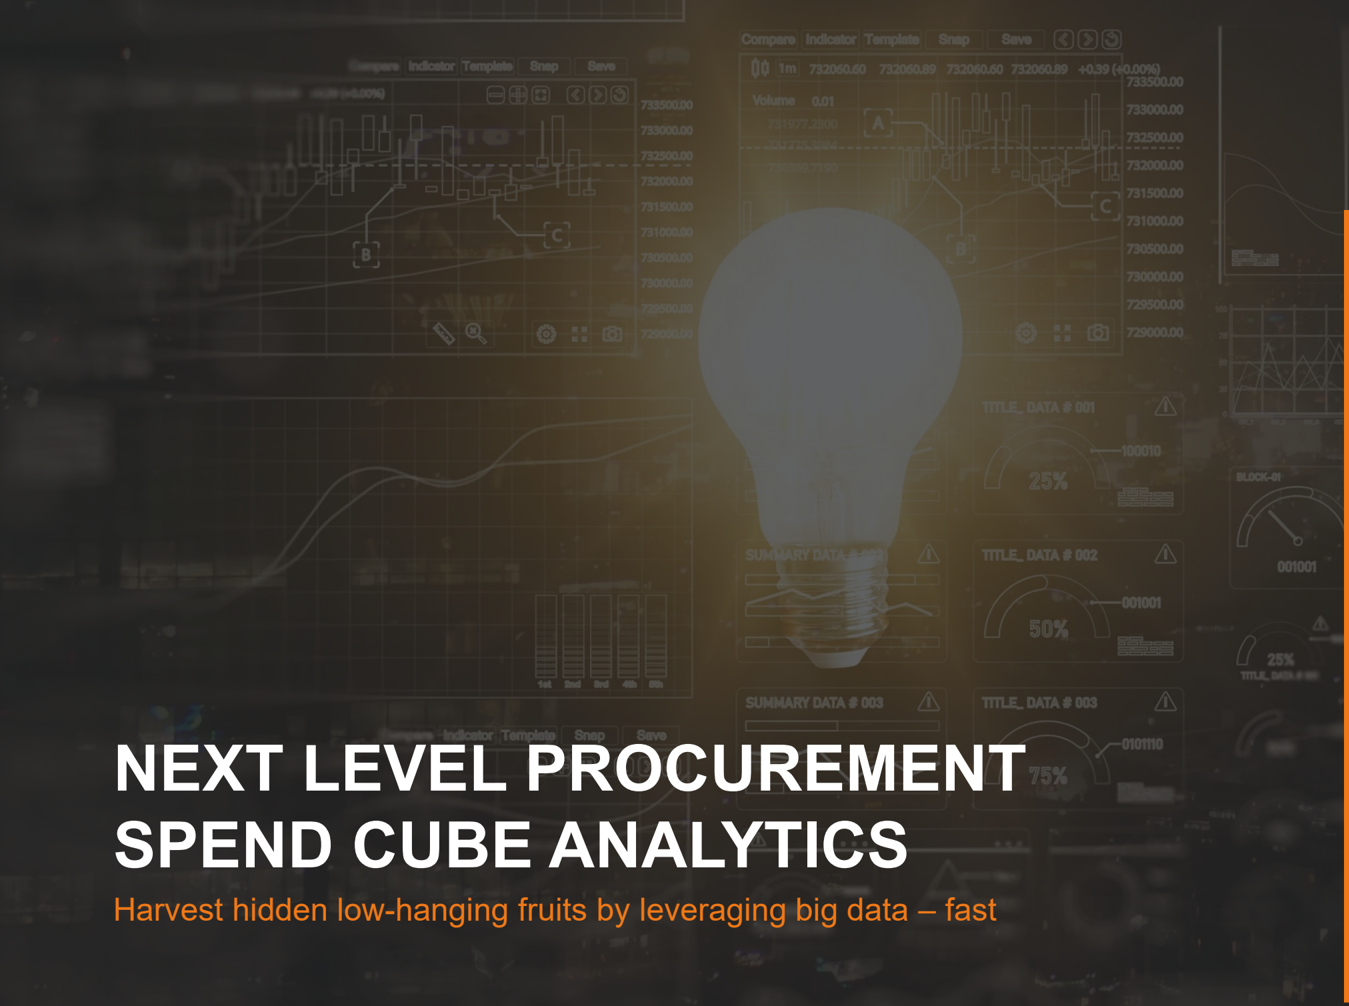


🖼️ Picture 2 | Page 1 | Class: logo (0.94) | Saved: scratch_docling_test\picture-2-page1.png


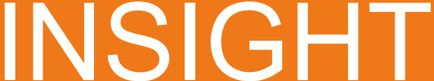


🖼️ Picture 3 | Page 2 | Class: bar_chart (0.98) | Saved: scratch_docling_test\picture-3-page2.png


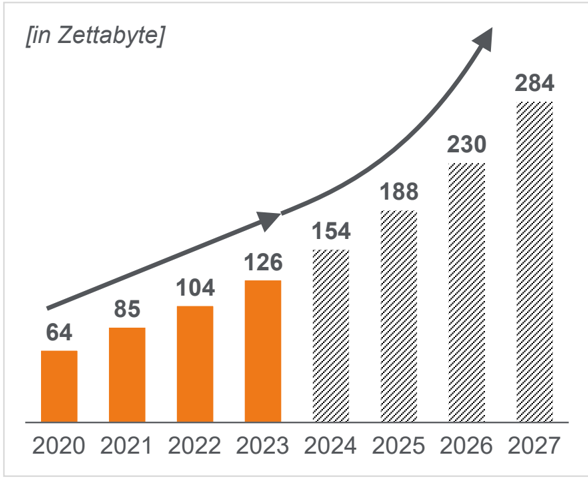


🖼️ Picture 4 | Page 2 | Class: logo (0.49) | Saved: scratch_docling_test\picture-4-page2.png


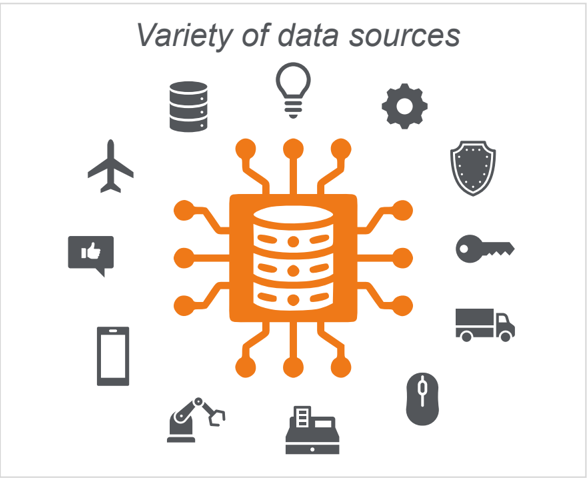


🖼️ Picture 5 | Page 2 | Class: flow_chart (0.34) | Saved: scratch_docling_test\picture-5-page2.png


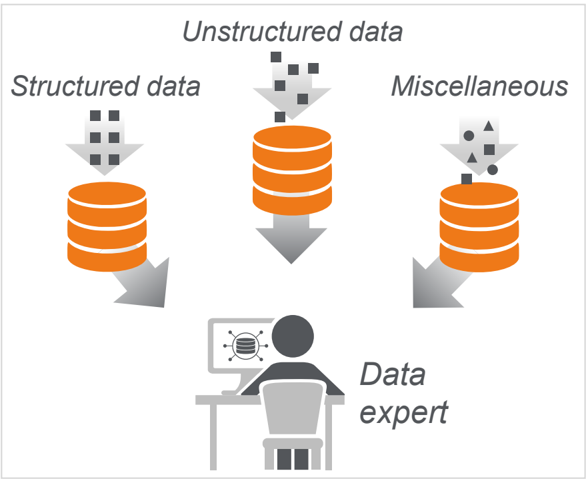


🖼️ Picture 6 | Page 2 | Class: icon (0.68) | Saved: scratch_docling_test\picture-6-page2.png


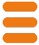


🖼️ Picture 7 | Page 3 | Class: screenshot_from_manual (0.22) | Saved: scratch_docling_test\picture-7-page3.png


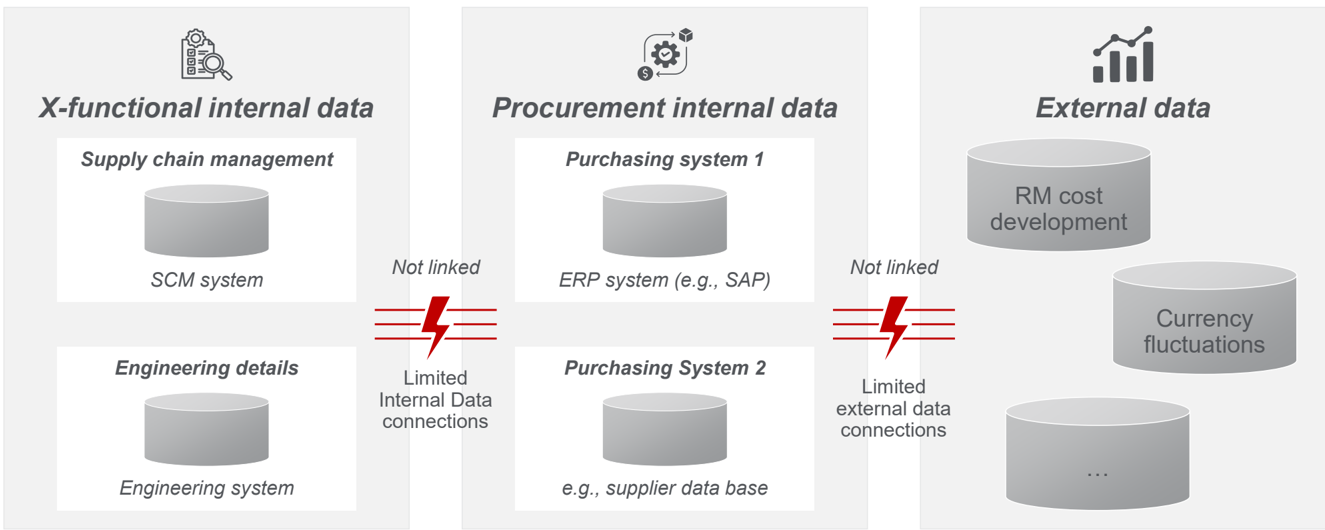


🖼️ Picture 8 | Page 3 | Class: icon (0.87) | Saved: scratch_docling_test\picture-8-page3.png


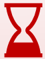


🖼️ Picture 9 | Page 3 | Class: icon (0.95) | Saved: scratch_docling_test\picture-9-page3.png


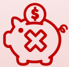


🖼️ Picture 10 | Page 3 | Class: icon (0.68) | Saved: scratch_docling_test\picture-10-page3.png


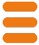


🖼️ Picture 11 | Page 4 | Class: screenshot_from_computer (0.71) | Saved: scratch_docling_test\picture-11-page4.png


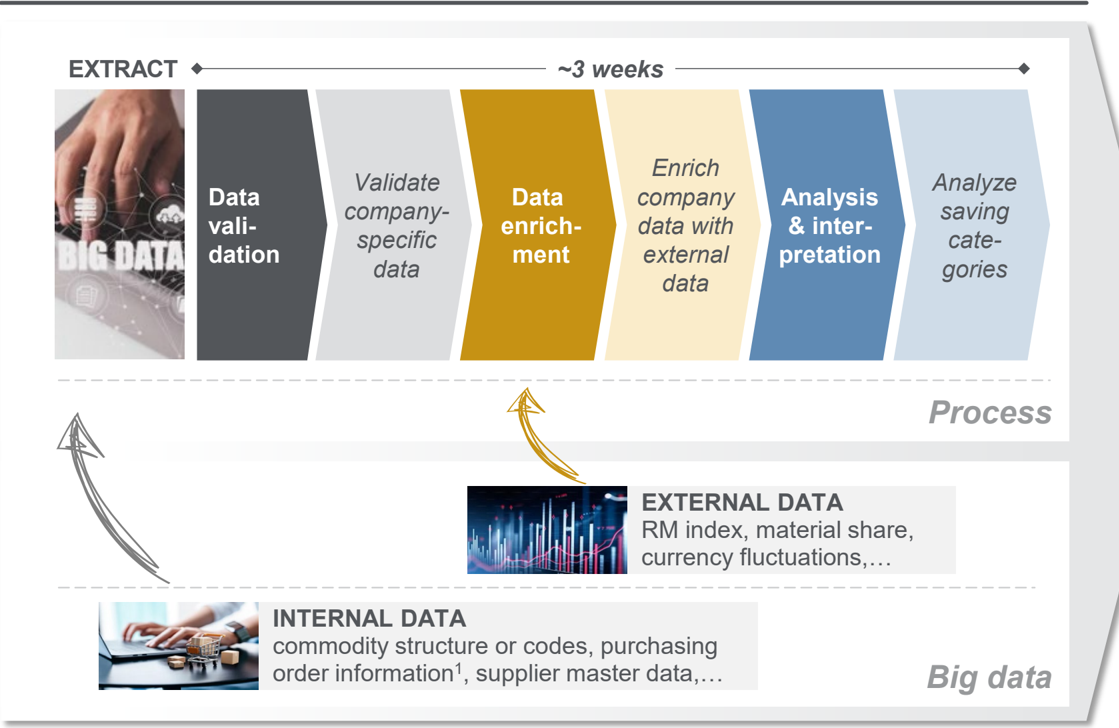


🖼️ Picture 12 | Page 4 | Class: table (0.37) | Saved: scratch_docling_test\picture-12-page4.png


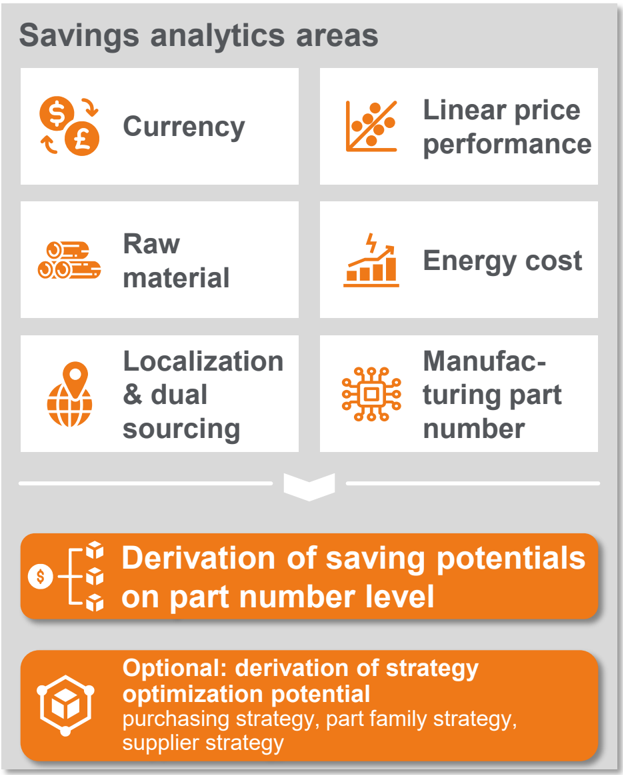


🖼️ Picture 13 | Page 5 | Class: bar_chart (0.89) | Saved: scratch_docling_test\picture-13-page5.png


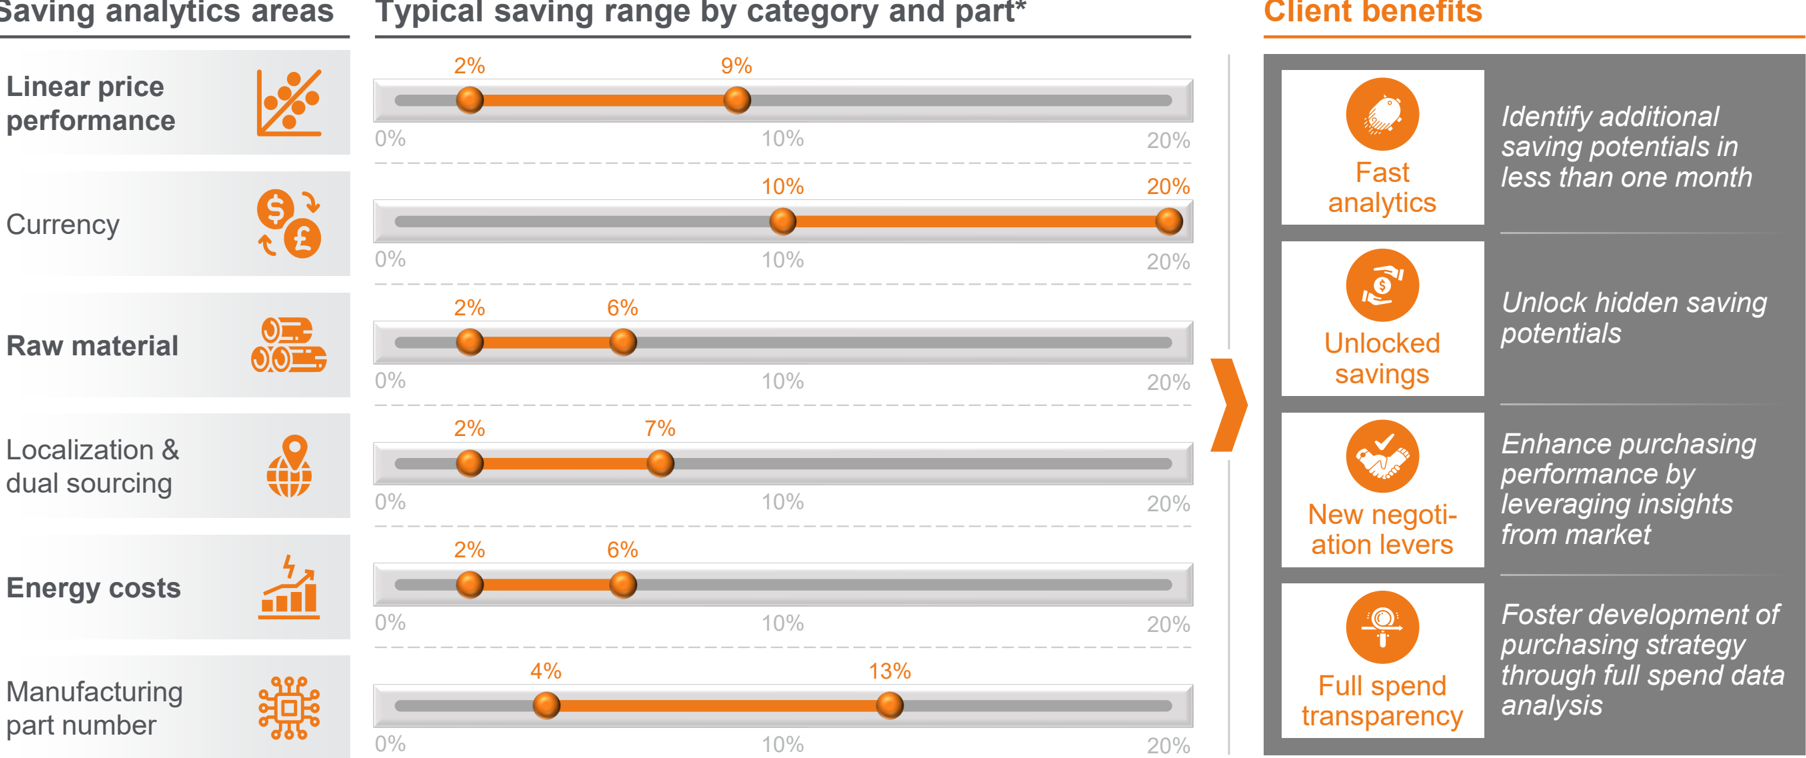


🖼️ Picture 14 | Page 6 | Class: logo (0.98) | Saved: scratch_docling_test\picture-14-page6.png


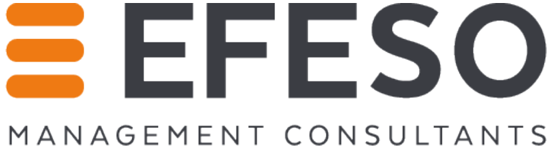


Total: 14 pictures, 0 tables detected


In [3]:
# Save all detected pictures as PNG files and show their classification
from IPython.display import display, Image as IPImage

picture_counter = 0
table_counter = 0

print("=" * 70)
print("DETECTED PICTURES — Saved to scratch_docling_test/")
print("=" * 70)

for element, _level in conv_res.document.iterate_items():
    if isinstance(element, PictureItem):
        picture_counter += 1
        page_no = element.prov[0].page_no if element.prov else "?"

        # Get classification
        classification = "not classified"
        if hasattr(element, "annotations") and element.annotations:
            for ann in element.annotations:
                if hasattr(ann, "predicted_classes") and ann.predicted_classes:
                    top = ann.predicted_classes[0]
                    classification = f"{top.class_name} ({top.confidence:.2f})"
                    break

        # Save image
        img_filename = OUTPUT_DIR / f"picture-{picture_counter}-page{page_no}.png"
        pil_img = element.get_image(conv_res.document)
        if pil_img:
            with img_filename.open("wb") as fp:
                pil_img.save(fp, "PNG")
            print(f"\n🖼️ Picture {picture_counter} | Page {page_no} | Class: {classification} | Saved: {img_filename}")
            display(IPImage(filename=str(img_filename), width=400))
        else:
            print(f"\n⚠️ Picture {picture_counter} | Page {page_no} | No image data available")

    elif isinstance(element, TableItem):
        table_counter += 1
        page_no = element.prov[0].page_no if element.prov else "?"
        img_filename = OUTPUT_DIR / f"table-{table_counter}-page{page_no}.png"
        pil_img = element.get_image(conv_res.document)
        if pil_img:
            with img_filename.open("wb") as fp:
                pil_img.save(fp, "PNG")
            print(f"\n📊 Table {table_counter} | Page {page_no} | Saved: {img_filename}")
            display(IPImage(filename=str(img_filename), width=400))

print(f"\n{'=' * 70}")
print(f"Total: {picture_counter} pictures, {table_counter} tables detected")

In [4]:
# Summary: What Docling detected per page
from collections import defaultdict

page_summary = defaultdict(lambda: {"text": 0, "pictures": 0, "tables": 0, "picture_classes": []})

for element, _level in conv_res.document.iterate_items():
    page_no = element.prov[0].page_no if hasattr(element, "prov") and element.prov else 0

    if isinstance(element, PictureItem):
        page_summary[page_no]["pictures"] += 1
        if hasattr(element, "annotations") and element.annotations:
            for ann in element.annotations:
                if hasattr(ann, "predicted_classes") and ann.predicted_classes:
                    page_summary[page_no]["picture_classes"].append(ann.predicted_classes[0].class_name)
    elif isinstance(element, TableItem):
        page_summary[page_no]["tables"] += 1
    else:
        page_summary[page_no]["text"] += 1

print(f"{'Page':<6} | {'Text':<6} | {'Pictures':<10} | {'Tables':<8} | {'Picture Classes'}")
print(f"{'─'*6}─┼─{'─'*6}─┼─{'─'*10}─┼─{'─'*8}─┼─{'─'*30}")
for page_no in sorted(page_summary.keys()):
    info = page_summary[page_no]
    classes = ", ".join(info["picture_classes"]) if info["picture_classes"] else "-"
    print(f"{page_no:<6} | {info['text']:<6} | {info['pictures']:<10} | {info['tables']:<8} | {classes}")

Page   | Text   | Pictures   | Tables   | Picture Classes
───────┼────────┼────────────┼──────────┼───────────────────────────────
1      | 6      | 2          | 0        | photograph, logo
2      | 8      | 4          | 0        | bar_chart, logo, flow_chart, icon
3      | 9      | 4          | 0        | screenshot_from_manual, icon, icon, icon
4      | 4      | 2          | 0        | screenshot_from_computer, table
5      | 1      | 1          | 0        | bar_chart
6      | 0      | 1          | 0        | logo


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\169132811.py:11: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  if hasattr(element, "annotations") and element.annotations:
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21988\169132811.py:12: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  for ann in element.annotations:
